# Phishing URL Detector

Langkah - langkah yang dikerjakan


1.   Loading data
2.   Familiar with data & EDA
3.   Visualisasi Data
4.   Spliting Data
5.   Training Data
6.   Comparison Model



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

## **1.   LOAD DATA**

In [ ]:
# load data gdrive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# load data csv
df = pd.read_csv('/content/drive/MyDrive/phishing URL detector/phishing.csv')
print(df.head())

   Index  UsingIP  LongURL  ShortURL  Symbol@  Redirecting//  PrefixSuffix-  \
0      0        1        1         1        1              1             -1   
1      1        1        0         1        1              1             -1   
2      2        1        0         1        1              1             -1   
3      3        1        0        -1        1              1             -1   
4      4       -1        0        -1        1             -1             -1   

   SubDomains  HTTPS  DomainRegLen  ...  UsingPopupWindow  IframeRedirection  \
0           0      1            -1  ...                 1                  1   
1          -1     -1            -1  ...                 1                  1   
2          -1     -1             1  ...                 1                  1   
3           1      1            -1  ...                -1                  1   
4           1      1            -1  ...                 1                  1   

   AgeofDomain  DNSRecording  WebsiteTraffic

## **2.   Familiar with Data & EDA**

In [3]:
# share of dataframe
df.shape

(11054, 32)

In [4]:
# listing features
df.columns

Index(['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//',
       'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon',
       'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL',
       'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL',
       'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
       'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
       'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage',
       'StatsReport', 'class'],
      dtype='object')

In [5]:
# information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

In [6]:
# unique value coloms
df.nunique()

Index                  11054
UsingIP                    2
LongURL                    3
ShortURL                   2
Symbol@                    2
Redirecting//              2
PrefixSuffix-              2
SubDomains                 3
HTTPS                      3
DomainRegLen               2
Favicon                    2
NonStdPort                 2
HTTPSDomainURL             2
RequestURL                 2
AnchorURL                  3
LinksInScriptTags          3
ServerFormHandler          3
InfoEmail                  2
AbnormalURL                2
WebsiteForwarding          2
StatusBarCust              2
DisableRightClick          2
UsingPopupWindow           2
IframeRedirection          2
AgeofDomain                2
DNSRecording               2
WebsiteTraffic             3
PageRank                   2
GoogleIndex                2
LinksPointingToPage        3
StatsReport                2
class                      2
dtype: int64

In [7]:
# droping index column
df.drop('Index', axis=1, inplace=True)

In [8]:
# describe dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UsingIP,11054.0,0.313914,0.949495,-1.0,-1.0,1.0,1.0,1.0
LongURL,11054.0,-0.633345,0.765973,-1.0,-1.0,-1.0,-1.0,1.0
ShortURL,11054.0,0.738737,0.674024,-1.0,1.0,1.0,1.0,1.0
Symbol@,11054.0,0.700561,0.713625,-1.0,1.0,1.0,1.0,1.0
Redirecting//,11054.0,0.741632,0.670837,-1.0,1.0,1.0,1.0,1.0
PrefixSuffix-,11054.0,-0.734938,0.678165,-1.0,-1.0,-1.0,-1.0,1.0
SubDomains,11054.0,0.064049,0.817492,-1.0,-1.0,0.0,1.0,1.0
HTTPS,11054.0,0.251040,0.911856,-1.0,-1.0,1.0,1.0,1.0
DomainRegLen,11054.0,-0.336711,0.941651,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11054.0,0.628551,0.777804,-1.0,1.0,1.0,1.0,1.0


1.   ada 11054 data dan 31 fitur dalam kumpulan
2.   30 fitur diantaranya adalah fitur independen dan 1 fitur dependen
3.   setiap fitur bertipe integer jadi tidak perlu melakukan label encoder
4.   tidak ada outlier dalam dataset
5.   tidak ada missing value pada dataset



## **3. VISUALISASI DATA**

beberapa plot dan grafik ditampilkan untuk menentukan bagaimana data di distribusikan dan bagaimana fitur saling terkait satu sama lain

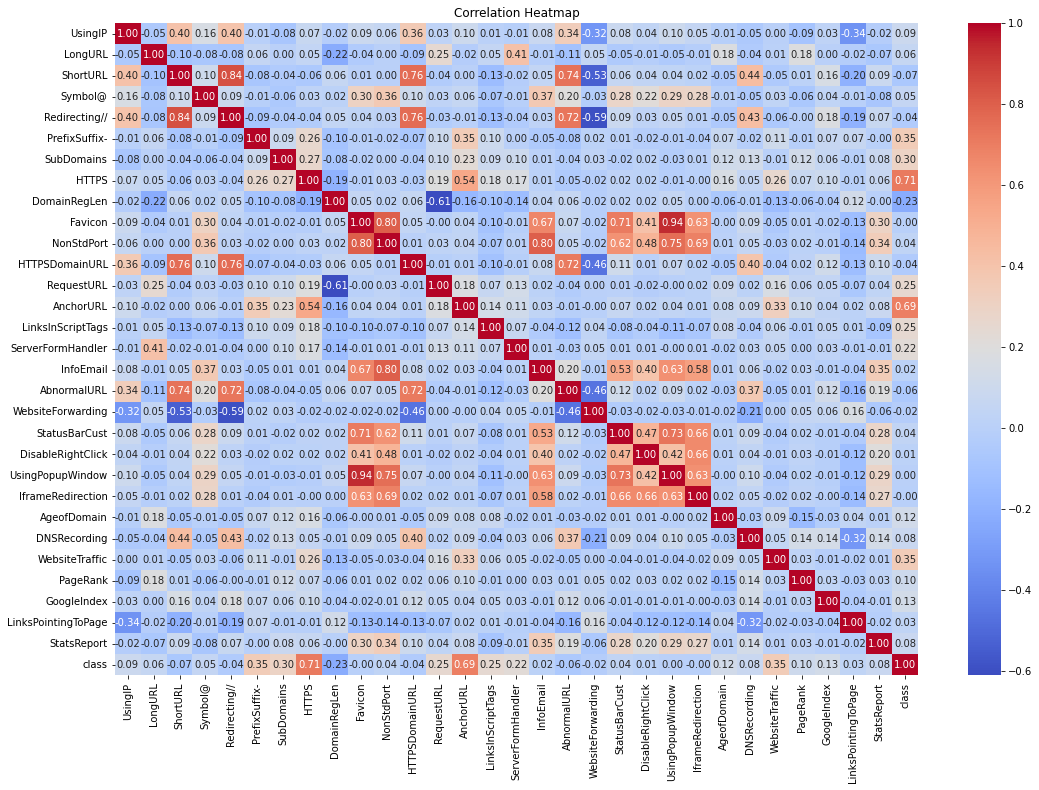

In [10]:
# 3. Korelasi antar fitur numerik
corr = df.corr()
plt.figure(figsize=(18, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

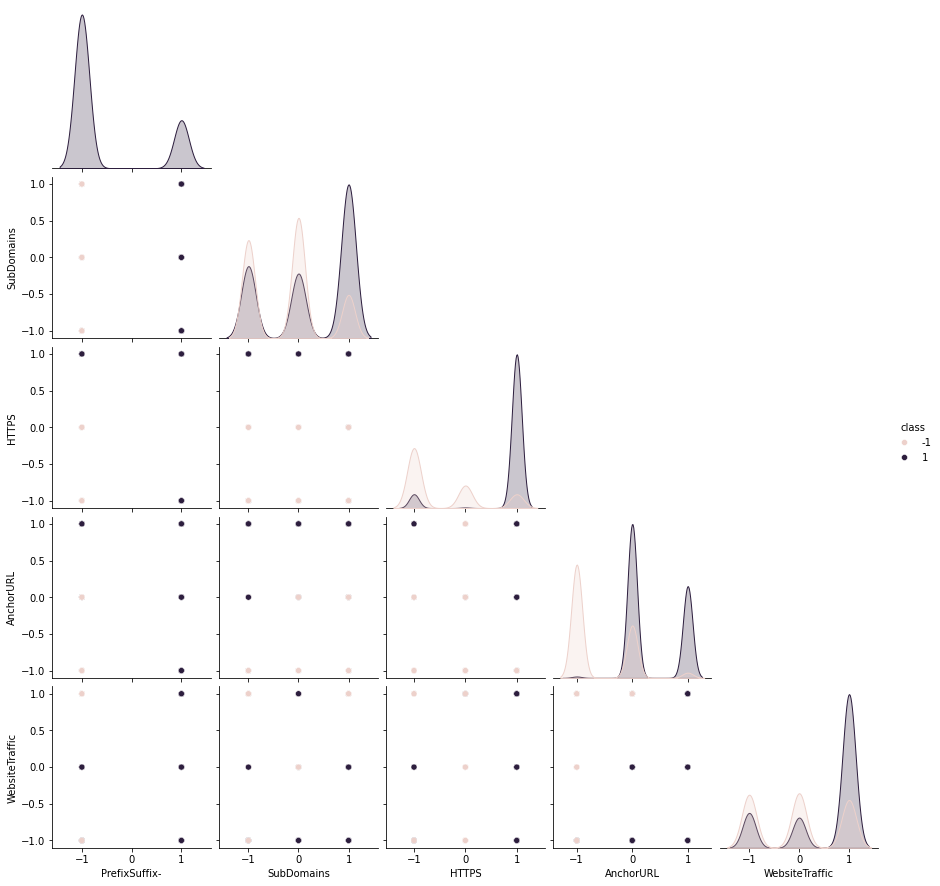

In [11]:
# pairplot for specific features
data = df[['PrefixSuffix-','SubDomains','HTTPS', 'AnchorURL', 'WebsiteTraffic','class']]
sns.pairplot(data, hue='class', corner=True)
plt.show()

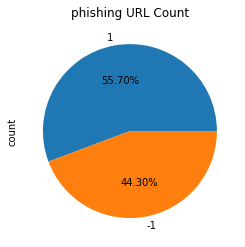

In [12]:
# phishing hitung dalam diagram lingkaran
df['class'].value_counts().plot(kind='pie', autopct='%1.2f%%')
plt.title('phishing URL Count')
plt.show()

In [ ]:
# memisahkan dataset menjadi fitur dependen dan independen
X = df.drop('class', axis = 1)
y = df['class']

In [ ]:
# membagi dataset menjadi set train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

## **4. Feature Selection**

In [ ]:

from sklearn.feature_selection import SelectKBest, f_classif

# Separate features (X) and target (y)
X = df_clean.drop('class', axis=1) # Use the cleaned data
y = df_clean['class']

# Select the top k features (you can adjust k)
k_best_features = SelectKBest(score_func=f_classif, k=15) # Example: selecting top 15 features
fit = k_best_features.fit(X, y)

# Get the selected features
selected_features_indices = fit.get_support(indices=True)
selected_features = X.columns[selected_features_indices]

print("Selected Features:")
print(selected_features)

# Update X with selected features
X_selected = X[selected_features]

print(df.columns)
print(df.head())

## **4. Splitting Data**

data dibagi menjadi data set pelatihan & data pengujian, dengan presentase pembagian 80 - 20

In [13]:
# memisahkan dataset menjadi fitur dependen dan independen
X = df.drop('class', axis = 1)
y = df['class']

In [14]:
# membagi dataset menjadi set train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

# **5. Model Building & Training**

1.   Logistic Regression
1.   K-Nearst Neighors
1.   support Vector Classifier
1.   Naive Bayes
2.   Decision Tree
2.   Random Forest
2.   Gradient Boosting
1.   Catboost
2.   Multiplayer perceptions

Matriks yang dipertimbangkan untuk mengevaluasi performa model adalah accuracy & F1 Score

In [15]:
# membuat holder untuk menyimpan hasil performa model
ml_model = []
accuracy = []
f1_score = []
recall = []
precision = []

# fungsi yang digunakan untuk memanggil dan menyimpan hasil
def storeResults(model, a, b, c, d):
  ml_model.append(model)
  accuracy.append(round(a, 3))
  f1_score.append(round(b, 3))
  recall.append(round(c, 3))
  precision.append(round(d, 3))

### **5.1 Logistic Regression**

metode analisis statistik yang digunakan untuk memprediksi probabilitas suatu peristiwa atau hasil berdasarkan nilai variabel independen. Metode ini sering digunakan dalam klasifikasi, terutama untuk masalah biner (dua kemungkinan hasil), seperti ya/tidak atau 0/1.

In [16]:
# linear reggression model
from sklearn.linear_model import LogisticRegression
#from sklearn.pipeline import Pipeline

# instantiate the model
lr = LogisticRegression()

#fit the model
lr.fit(X_train, y_train)

LogisticRegression()

In [17]:
# prediksi nilai target dari model untuk sample

y_train_lr = lr.predict(X_train)
y_test_lr = lr.predict(X_test)

In [18]:
# computing the accuracy, f1_score, recall, precision of the model performance

acc_train_lr = metrics.accuracy_score(y_train, y_train_lr)
acc_test_lr = metrics.accuracy_score(y_test, y_test_lr)
print ("logistic regression : accuracy in train data is: {:.3f}". format(acc_train_lr))
print ("logistic regression : accuracy in test data is: {:.3f}". format(acc_test_lr))

f1_score_train_lr = metrics.f1_score(y_train, y_train_lr)
f1_score_test_lr = metrics.f1_score(y_test, y_test_lr)
print ("logistic regression : f1_score in train data is: {:.3f}". format(f1_score_train_lr))
print ("logistic regression : f1_score in test data is: {:.3f}". format(f1_score_test_lr))

recall_train_lr = metrics.recall_score(y_train, y_train_lr)
recall_test_lr = metrics.recall_score(y_test, y_test_lr)
print ("logistic regression : recall in train data is: {:.3f}". format(recall_train_lr))
print ("logistic regression : recall in test data is: {:.3f}". format(recall_test_lr))

precision_train_lr = metrics.precision_score(y_train, y_train_lr)
precision_test_lr = metrics.precision_score(y_test, y_test_lr)
print ("logistic regression : precision in train data is: {:.3f}". format(precision_train_lr))
print ("logistic regression : precision in test data is: {:.3f}". format(precision_test_lr))

logistic regression : accuracy in train data is: 0.927
logistic regression : accuracy in test data is: 0.934
logistic regression : f1_score in train data is: 0.935
logistic regression : f1_score in test data is: 0.941
logistic regression : recall in train data is: 0.943
logistic regression : recall in test data is: 0.953
logistic regression : precision in train data is: 0.927
logistic regression : precision in test data is: 0.930


In [19]:
# computing the classification report of the model
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_lr))

              precision    recall  f1-score   support

          -1       0.94      0.91      0.92       976
           1       0.93      0.95      0.94      1235

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



In [20]:
# storing the result

storeResults('Logistic Regression', acc_test_lr, f1_score_test_lr, recall_test_lr, precision_test_lr)

### **5.2 K-Nearest Neighbors (KNN)**

Algoritma non-parametrik yang digunakan untuk klasifikasi dan regresi. Untuk klasifikasi, objek diklasifikasikan berdasarkan mayoritas suara dari tetangga terdekatnya (K).

In [21]:
# K-Nearest Neighbors(KNN) model
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model
knn = KNeighborsClassifier(n_neighbors=1)

#fit the model
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [22]:
#predicting the target value from model
y_train_knn = knn.predict(X_train)
y_test_knn = knn.predict(X_test)

In [23]:
# computing the accuracy, f1_score, recall, precision of the model performance

acc_train_knn = metrics.accuracy_score(y_train, y_train_knn)
acc_test_knn = metrics.accuracy_score(y_test, y_test_knn)

print ("KNN : accuracy in train data is: {:.3f}". format(acc_train_knn))
print ("KNN : accuracy in test data is: {:.3f}". format(acc_test_knn))

f1_score_train_knn = metrics.f1_score(y_train, y_train_knn)
f1_score_test_knn = metrics.f1_score(y_test, y_test_knn)

print ("KNN : f1_score in train data is: {:.3f}". format(f1_score_train_knn))
print ("KNN : f1_score in test data is: {:.3f}". format(f1_score_test_knn))

recall_train_knn = metrics.recall_score(y_train, y_train_knn)
recall_test_knn = metrics.recall_score(y_test, y_test_knn)

print ("KNN : recall in train data is: {:.3f}". format(recall_train_knn))
print ("KNN : recall in test data is: {:.3f}". format(recall_test_knn))

precision_train_knn = metrics.precision_score(y_train, y_train_knn)
precision_test_knn = metrics.precision_score(y_test, y_test_knn)

print ("KNN : precision in train data is: {:.3f}". format(precision_train_knn))
print ("KNN : precision in test data is: {:.3f}". format(precision_test_knn))


KNN : accuracy in train data is: 0.988
KNN : accuracy in test data is: 0.959
KNN : f1_score in train data is: 0.990
KNN : f1_score in test data is: 0.963
KNN : recall in train data is: 0.988
KNN : recall in test data is: 0.964
KNN : precision in train data is: 0.991
KNN : precision in test data is: 0.963


In [24]:
# computing the classification report of the model

print(classification_report(y_test, y_test_knn))

              precision    recall  f1-score   support

          -1       0.95      0.95      0.95       976
           1       0.96      0.96      0.96      1235

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



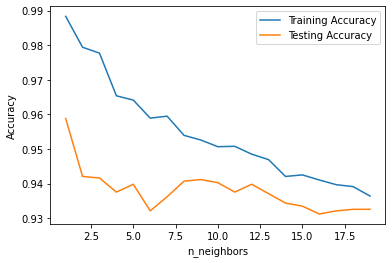

In [25]:
train_accuracy = []
test_accuracy = []
#try max_depth from 1 to 20
depth = range(1,20)
for i in depth:
  knn = KNeighborsClassifier(n_neighbors=i)

  knn.fit(X_train, y_train)

  train_accuracy.append(knn.score(X_train, y_train))
  test_accuracy.append(knn.score(X_test, y_test))


#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.plot(depth, train_accuracy, label='Training Accuracy')
plt.plot(depth, test_accuracy, label='Testing Accuracy')
plt.xlabel('n_neighbors')
plt.ylabel('Accuracy')
plt.legend();

In [26]:
# storing the result

storeResults('K-Nearest Neighbors', acc_test_knn, f1_score_test_knn, recall_test_knn, precision_test_knn)

### **5.3 Support Vector Classifier (SVC)**
Model diskriminatif formal yang didefinisikan oleh hyperplane pemisah. Diberikan satu set contoh pelatihan, masing-masing ditandai sebagai milik salah satu dari dua kategori, algoritma pelatihan SVC membangun model yang menetapkan contoh baru ke salah satu dari dua kategori tersebut, menjadikannya pengklasifikasi biner non-probabilistik linier.

In [ ]:
# Support Vector Classifier model
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'gamma': [0.1], 'kernel' : ['rbf', 'linear']}

svc = GridSearchCV(SVC(), param_grid)

#fit the model
svc.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'gamma': [0.1], 'kernel': ['rbf', 'linear']})

In [ ]:
# predicting the target value from the model for the samples
y_train_svc = svc.predict(X_train)
y_test_svc = svc.predict(X_test)

In [ ]:
# computing the accuracy, f1_score, recall, precision of the model performance

acc_train_svc = metrics.accuracy_score(y_train, y_train_svc)
acc_test_svc = metrics.accuracy_score(y_test, y_test_svc)

print ("SVC : accuracy in train data is: {:.3f}". format(acc_train_svc))
print ("SVC : accuracy in test data is: {:.3f}". format(acc_test_svc))

f1_score_train_svc = metrics.f1_score(y_train, y_train_svc)
f1_score_test_svc = metrics.f1_score(y_test, y_test_svc)

print ("SVC : f1_score in train data is: {:.3f}". format(f1_score_train_svc))
print ("SVC : f1_score in test data is: {:.3f}". format(f1_score_test_svc))

recall_score_train_svc = metrics.recall_score(y_train, y_train_svc)
recall_score_test_svc = metrics.recall_score(y_test, y_test_svc)

print ("SVC : recall in train data is: {:.3f}". format(recall_score_train_svc))
print ("SVC : recall in test data is: {:.3f}". format(recall_score_test_svc))

precision_score_train_svc = metrics.precision_score(y_train, y_train_svc)
precision_score_test_svc = metrics.precision_score(y_test, y_test_svc)

print ("SVC : precision in train data is: {:.3f}". format(precision_score_train_svc))
print ("SVC : precision in test data is: {:.3f}". format(precision_score_test_svc))

SVC : accuracy in train data is: 0.969
SVC : accuracy in test data is: 0.964
SVC : f1_score in train data is: 0.973
SVC : f1_score in test data is: 0.968
SVC : recall in train data is: 0.980
SVC : recall in test data is: 0.980
SVC : precision in train data is: 0.965
SVC : precision in test data is: 0.957


In [ ]:
# computing the classification report of the model

print(classification_report(y_test, y_test_svc))

              precision    recall  f1-score   support

          -1       0.97      0.94      0.96       976
           1       0.96      0.98      0.97      1235

    accuracy                           0.96      2211
   macro avg       0.97      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



In [ ]:
# storing the result

storeResults('Support Vector Machine', acc_test_svc, f1_score_test_svc, recall_score_test_svc, precision_score_test_svc)

### **5.4 Naive Bayes**
Sekumpulan algoritma klasifikasi sederhana yang didasarkan pada teorema Bayes dengan asumsi independensi yang kuat antara fitur. Model ini sangat cepat untuk dilatih dan digunakan, dan seringkali bekerja dengan baik pada data berdimensi tinggi.


In [ ]:
# naive bayes classifier model
from sklearn.naive_bayes import GaussianNB

# instantiate the model
nb = GaussianNB()

#fit the model
nb.fit(X_train, y_train)

GaussianNB()

In [ ]:
# predicting the target value from model for the sample
y_train_nb = nb.predict(X_train)
y_test_nb = nb.predict(X_test)

In [ ]:
# computing the accuracy, f1_score, recall, precision of the model performance
acc_train_nb = metrics.accuracy_score(y_train, y_train_nb)
acc_test_nb = metrics.accuracy_score(y_test, y_test_nb)

print ("Naive Bayes : accuracy in train data is: {:.3f}". format(acc_train_nb))
print ("Naive Bayes : accuracy in test data is: {:.3f}". format(acc_test_nb))

f1_score_train_nb = metrics.f1_score(y_train, y_train_nb)
f1_score_test_nb = metrics.f1_score(y_test, y_test_nb)

print ("Naive Bayes : f1_score in train data is: {:.3f}". format(f1_score_train_nb))
print ("Naive Bayes : f1_score in test data is: {:.3f}". format(f1_score_test_nb))

recall_score_train_nb = metrics.recall_score(y_train, y_train_nb)
recall_score_test_nb = metrics.recall_score(y_test, y_test_nb)

print ("Naive Bayes : recall in train data is: {:.3f}". format(recall_score_train_nb))
print ("Naive Bayes : recall in test data is: {:.3f}". format(recall_score_test_nb))

precision_score_train_nb = metrics.precision_score(y_train, y_train_nb)
precision_score_test_nb = metrics.precision_score(y_test, y_test_nb)

print ("Naive Bayes : precision in train data is: {:.3f}". format(precision_score_train_nb))
print ("Naive Bayes : precision in test data is: {:.3f}". format(precision_score_test_nb))

Naive Bayes : accuracy in train data is: 0.605
Naive Bayes : accuracy in test data is: 0.605
Naive Bayes : f1_score in train data is: 0.451
Naive Bayes : f1_score in test data is: 0.454
Naive Bayes : recall in train data is: 0.292
Naive Bayes : recall in test data is: 0.294
Naive Bayes : precision in train data is: 0.997
Naive Bayes : precision in test data is: 0.995


In [ ]:
# computing the classification report the model
print(classification_report(y_test, y_test_nb))

              precision    recall  f1-score   support

          -1       0.53      1.00      0.69       976
           1       0.99      0.29      0.45      1235

    accuracy                           0.60      2211
   macro avg       0.76      0.65      0.57      2211
weighted avg       0.79      0.60      0.56      2211



In [ ]:
# storing the results

storeResults('Naive Bayes', acc_test_nb, f1_score_test_nb, recall_score_test_nb,
             precision_score_test_nb)

### **5.5 Decision Tree**
Algoritma pembelajaran supervised non-parametrik yang digunakan untuk klasifikasi dan regresi. Model ini membentuk pohon keputusan berdasarkan fitur data, di mana setiap node internal mewakili "tes" pada atribut, setiap cabang mewakili hasil dari tes tersebut, dan setiap node daun mewakili label kelas atau nilai target.

In [ ]:
# decision Tree classifier model
from sklearn.tree import DecisionTreeClassifier

# instantiate the model
dt = DecisionTreeClassifier(max_depth=30)

#fit the model
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30)

In [ ]:
# predicting the target value from the model
y_train_dt = dt.predict(X_train)
y_test_dt = dt.predict(X_test)

In [ ]:
# computing the accuracy, f1_score, recall, precision of the model performance
acc_train_dt = metrics.accuracy_score(y_train, y_train_dt)
acc_test_dt = metrics.accuracy_score(y_test, y_test_dt)

print ("Decision Tree : accuracy in train data is: {:.3f}". format(acc_train_dt))
print ("Decision Tree : accuracy in test data is: {:.3f}". format(acc_test_dt))

f1_score_train_dt = metrics.f1_score(y_train, y_train_dt)
f1_score_test_dt = metrics.f1_score(y_test, y_test_dt)

print ("Decision Tree : f1_score in train data is: {:.3f}". format(f1_score_train_dt))
print ("Decision Tree : f1_score in test data is: {:.3f}". format(f1_score_test_dt))

recall_score_train_dt = metrics.recall_score(y_train, y_train_dt)
recall_score_test_dt = metrics.recall_score(y_test, y_test_dt)

print ("Decision Tree : recall in train data is: {:.3f}". format(recall_score_train_dt))
print ("Decision Tree : recall in test data is: {:.3f}". format(recall_score_test_dt))

precision_score_train_dt = metrics.precision_score(y_train, y_train_dt)
precision_score_test_dt = metrics.precision_score(y_test, y_test_dt)

print ("Decision Tree : precision in train data is: {:.3f}". format(precision_score_train_dt))
print ("Decision Tree : precision in test data is: {:.3f}". format(precision_score_test_dt))

Decision Tree : accuracy in train data is: 0.991
Decision Tree : accuracy in test data is: 0.960
Decision Tree : f1_score in train data is: 0.992
Decision Tree : f1_score in test data is: 0.964
Decision Tree : recall in train data is: 0.991
Decision Tree : recall in test data is: 0.962
Decision Tree : precision in train data is: 0.993
Decision Tree : precision in test data is: 0.967


In [ ]:
# computing the classification report the model

print(metrics.classification_report(y_test, y_test_dt))

              precision    recall  f1-score   support

          -1       0.95      0.96      0.96       976
           1       0.97      0.96      0.96      1235

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



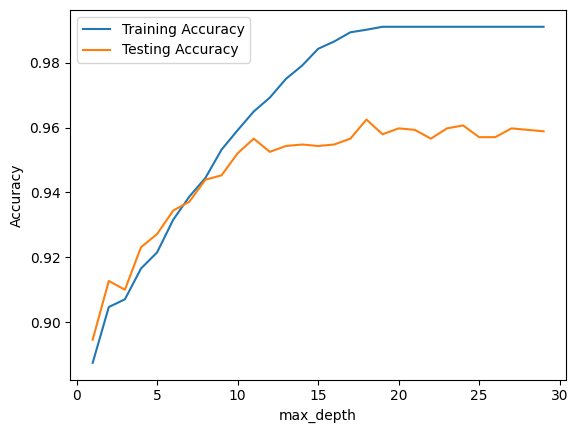

In [ ]:
train_accuracy = []
test_accuracy = []
#try max_depth from 1 to 20
depth = range(1,30)
for i in depth:
  dt_test = DecisionTreeClassifier(max_depth=i)

  dt_test.fit(X_train, y_train)
  #record training set accuracy
  train_accuracy.append(dt_test.score(X_train, y_train))
  #record generalization accuracy
  test_accuracy.append(dt_test.score(X_test, y_test))

#plotting the training & testing accuracy for max_depth from 1 to 30
plt.plot(depth, train_accuracy, label='Training Accuracy')
plt.plot(depth, test_accuracy, label='Testing Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend();

In [ ]:
# storing Result

storeResults('Decision Tree', acc_test_dt, f1_score_test_dt, recall_score_test_dt,
             precision_score_test_dt)

### **5.6 Random Forest**
Metode pembelajaran ensemble yang digunakan untuk klasifikasi dan regresi. Model ini membangun banyak pohon keputusan selama fase pelatihan dan menghasilkan kelas yang merupakan mode (klasifikasi) atau prediksi rata-rata (regresi) dari prediksi pohon individu. Ini membantu mengurangi overfitting.

In [ ]:
# random forest classifier model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
rf = RandomForestClassifier(n_estimators=10)

#fit the model
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10)

In [ ]:
# predicting the target value from model for the sample
y_train_rf = rf.predict(X_train)
y_test_rf = rf.predict(X_test)

In [ ]:
# # computing the accuracy, f1_score, recall, precision of the model performance
acc_train_rf = metrics.accuracy_score(y_train, y_train_rf)
acc_test_rf = metrics.accuracy_score(y_test, y_test_rf)

print ("Random Forest : accuracy in train data is: {:.3f}". format(acc_train_rf))
print ("Random Forest : accuracy in test data is: {:.3f}". format(acc_test_rf))

f1_score_train_rf = metrics.f1_score(y_train, y_train_rf)
f1_score_test_rf = metrics.f1_score(y_test, y_test_rf)

print ("Random Forest : f1_score in train data is: {:.3f}". format(f1_score_train_rf))
print ("Random Forest : f1_score in test data is: {:.3f}". format(f1_score_test_rf))

recall_score_train_rf = metrics.recall_score(y_train, y_train_rf)
recall_score_test_rf = metrics.recall_score(y_test, y_test_rf)

print ("Random Forest : recall in train data is: {:.3f}". format(recall_score_train_rf))
print ("Random Forest : recall in test data is: {:.3f}". format(recall_score_test_rf))

precision_score_train_rf = metrics.precision_score(y_train, y_train_rf)
precision_score_test_rf = metrics.precision_score(y_test, y_test_rf)

print ("Random Forest : precision in train data is: {:.3f}". format(precision_score_train_rf))
print ("Random Forest : precision in test data is: {:.3f}". format(precision_score_test_rf))

Random Forest : accuracy in train data is: 0.990
Random Forest : accuracy in test data is: 0.966
Random Forest : f1_score in train data is: 0.991
Random Forest : f1_score in test data is: 0.970
Random Forest : recall in train data is: 0.994
Random Forest : recall in test data is: 0.976
Random Forest : precision in train data is: 0.988
Random Forest : precision in test data is: 0.964


In [ ]:
# computing the classification report of the model

print(classification_report(y_test, y_test_rf))

              precision    recall  f1-score   support

          -1       0.97      0.95      0.96       976
           1       0.96      0.98      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.96      0.97      2211
weighted avg       0.97      0.97      0.97      2211



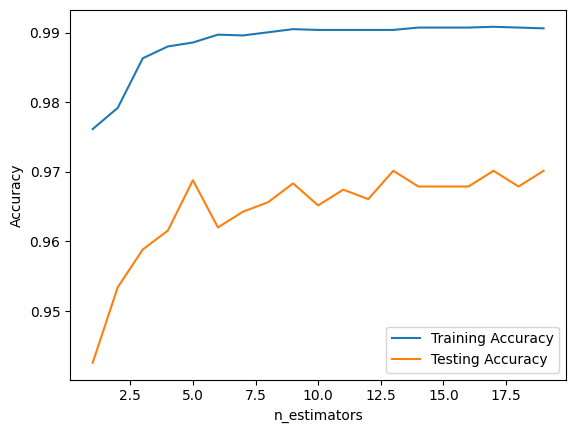

In [ ]:
train_accuracy = []
test_accuracy = []
#try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
  rf_test = RandomForestClassifier(n_estimators=n)

  rf_test.fit(X_train, y_train)
  #record training set accuracy
  train_accuracy.append(rf_test.score(X_train, y_train))
  #record generalization accuracy
  test_accuracy.append(rf_test.score(X_test, y_test))

  #plotting the training & testing accuracy for n_estimators from 1 to 20
plt.plot(depth, train_accuracy, label='Training Accuracy')
plt.plot(depth, test_accuracy, label='Testing Accuracy')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.legend();


In [ ]:
# storing result

storeResults('Random Forest', acc_test_rf, f1_score_test_rf, recall_score_test_rf,
             precision_score_test_rf)

### **5.7 Gradient Boosting**
Teknik pembelajaran ensemble lainnya yang membangun model secara sekuensial, di mana setiap model baru mencoba memperbaiki kesalahan yang dibuat oleh model sebelumnya. Ini sering kali menghasilkan model yang sangat akurat.

In [ ]:
# gradient boosting classifier model
from sklearn.ensemble import GradientBoostingClassifier

# instantiate the model
gb = GradientBoostingClassifier(learning_rate=0.7, max_depth=4)

#fit the model
gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.7, max_depth=4)

In [ ]:
# predicting the target value from model for the sample
y_train_gb = gb.predict(X_train)
y_test_gb = gb.predict(X_test)

In [ ]:
# computing the accuracy, f1_score, recall, precision of the model performance
acc_train_gb = metrics.accuracy_score(y_train, y_train_gb)
acc_test_gb = metrics.accuracy_score(y_test, y_test_gb)

print ("Gradient Boosting : accuracy on train data is: {:.3f}". format(acc_train_gb))
print ("Gradient Boosting : accuracy on test data is: {:.3f}". format(acc_test_gb))

f1_score_train_gb = metrics.f1_score(y_train, y_train_gb)
f1_score_test_gb = metrics.f1_score(y_test, y_test_gb)

print ("Gradient Boosting : f1_score on train data is: {:.3f}". format(f1_score_train_gb))
print ("Gradient Boosting : f1_score on test data is: {:.3f}". format(f1_score_test_gb))

recall_score_train_gb = metrics.recall_score(y_train, y_train_gb)
recall_score_test_gb = metrics.recall_score(y_test, y_test_gb)

print ("Gradient Boosting : recall on train data is: {:.3f}". format(recall_score_train_gb))
print ("Gradient Boosting : recall on test data is: {:.3f}". format(recall_score_test_gb))

precision_score_train_gb = metrics.precision_score(y_train, y_train_gb)
precision_score_test_gb = metrics.precision_score(y_test, y_test_gb)

print ("Gradient Boosting : precision on train data is: {:.3f}". format(precision_score_train_gb))
print ("Gradient Boosting : precision on test data is: {:.3f}". format(precision_score_test_gb))

Gradient Boosting : accuracy on train data is: 0.989
Gradient Boosting : accuracy on test data is: 0.974
Gradient Boosting : f1_score on train data is: 0.990
Gradient Boosting : f1_score on test data is: 0.977
Gradient Boosting : recall on train data is: 0.994
Gradient Boosting : recall on test data is: 0.989
Gradient Boosting : precision on train data is: 0.986
Gradient Boosting : precision on test data is: 0.966


In [ ]:
# computing the classification report of model
print(classification_report(y_test, y_test_gb))

              precision    recall  f1-score   support

          -1       0.99      0.96      0.97       976
           1       0.97      0.99      0.98      1235

    accuracy                           0.97      2211
   macro avg       0.98      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



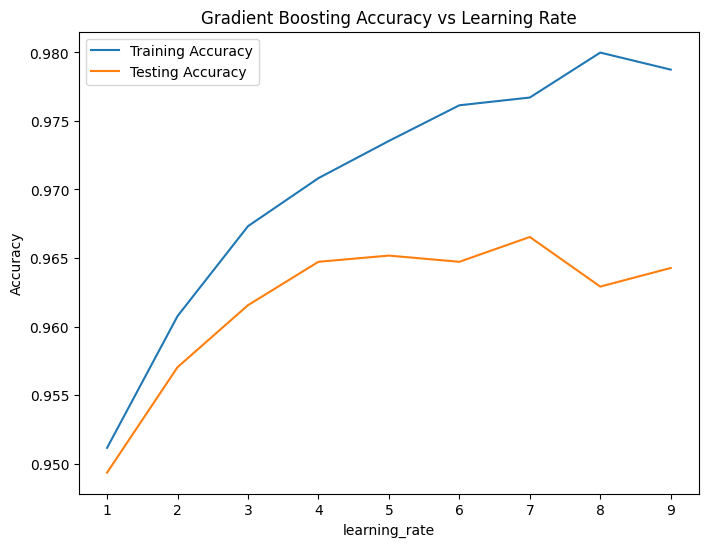

In [ ]:
training_accuracy = []
test_accuracy = []
#try lerning_rate from 0.1 to 0.9
depth = range(1,10) # Tetap gunakan range(1,10) untuk 9 nilai
for n in depth:
  # Gunakan n * 0.1 untuk learning_rate antara 0.1 hingga 0.9
  gb_test = GradientBoostingClassifier(learning_rate=n*0.1)

  gb_test.fit(X_train, y_train)
  #record training set accuracy
  training_accuracy.append(gb_test.score(X_train, y_train))
  #record generalization accuracy
  test_accuracy.append(gb_test.score(X_test, y_test))

#plotting the training & testing accuracy after the loop finishes
plt.figure(figsize=(8, 6)) # Menambahkan ukuran figure
plt.plot(depth, training_accuracy, label='Training Accuracy')
plt.plot(depth, test_accuracy, label='Testing Accuracy')
plt.xlabel('learning_rate') # Mengganti label sumbu x menjadi learning_rate
plt.ylabel('Accuracy')
plt.legend()
plt.title('Gradient Boosting Accuracy vs Learning Rate') # Menambahkan judul plot
plt.show() # Menambahkan plt.show() untuk menampilkan plot

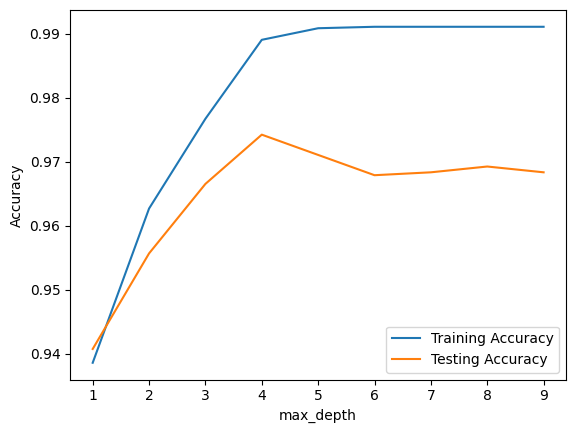

In [ ]:
train_accuracy = []
test_accuracy = []

# try learning_rate from 0.1 to 0.9
depth = range(1,10,1)
for n in depth:
  gbc_test = GradientBoostingClassifier(max_depth=n, learning_rate=0.7)

  gbc_test.fit(X_train, y_train)
  #record training set accuracy
  train_accuracy.append(gbc_test.score(X_train, y_train))
  #record generalization accuracy
  test_accuracy.append(gbc_test.score(X_test, y_test))

  #plotting the training & testing accuracy for max_depth from 1 to 9
plt.plot(depth, train_accuracy, label='Training Accuracy')
plt.plot(depth, test_accuracy, label='Testing Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend();

In [ ]:
#storing results

storeResults('Gradient Boosting', acc_test_gb, f1_score_test_gb, recall_score_test_gb,
             precision_score_test_gb)

### **5.8 CatBoost**
 Algoritma gradient boosting open-source yang dikembangkan oleh Yandex. CatBoost dirancang khusus untuk menangani variabel kategori secara efisien dan seringkali memberikan hasil yang sangat baik.

In [ ]:
!pip install catboost

In [ ]:
# CatBoost Classifier model
from catboost import CatBoostClassifier

# instantiate the model
cb = CatBoostClassifier(learning_rate = 0.1)

#fit the model
cb.fit(X_train, y_train)

0:	learn: 0.5487232	total: 73.2ms	remaining: 1m 13s
1:	learn: 0.4349357	total: 103ms	remaining: 51.4s
2:	learn: 0.3609236	total: 119ms	remaining: 39.6s
3:	learn: 0.3050829	total: 130ms	remaining: 32.4s
4:	learn: 0.2766620	total: 141ms	remaining: 28s
5:	learn: 0.2475476	total: 152ms	remaining: 25.2s
6:	learn: 0.2286637	total: 163ms	remaining: 23.1s
7:	learn: 0.2138754	total: 174ms	remaining: 21.5s
8:	learn: 0.2013643	total: 183ms	remaining: 20.2s
9:	learn: 0.1896378	total: 192ms	remaining: 19s
10:	learn: 0.1819539	total: 207ms	remaining: 18.6s
11:	learn: 0.1767867	total: 218ms	remaining: 17.9s
12:	learn: 0.1727735	total: 229ms	remaining: 17.4s
13:	learn: 0.1682578	total: 239ms	remaining: 16.8s
14:	learn: 0.1641759	total: 248ms	remaining: 16.3s
15:	learn: 0.1614218	total: 258ms	remaining: 15.9s
16:	learn: 0.1558968	total: 269ms	remaining: 15.5s
17:	learn: 0.1535881	total: 283ms	remaining: 15.5s
18:	learn: 0.1514228	total: 294ms	remaining: 15.2s
19:	learn: 0.1482580	total: 304ms	remaining

In [ ]:
# predicting the target value from model for the sample
y_train_cb = cb.predict(X_train)
y_test_cb = cb.predict(X_test)

In [ ]:
# computing the accuracy, f1_score, recall, precision of the model performance
acc_train_cb = metrics.accuracy_score(y_train, y_train_cb)
acc_test_cb = metrics.accuracy_score(y_test, y_test_cb)

print ("CatBoost : accuracy on train data is: {:.3f}". format(acc_train_cb))
print ("CatBoost : accuracy on test data is: {:.3f}". format(acc_test_cb))

f1_score_train_cb = metrics.f1_score(y_train, y_train_cb)
f1_score_test_cb = metrics.f1_score(y_test, y_test_cb)

print ("CatBoost : f1_score on train data is: {:.3f}". format(f1_score_train_cb))
print ("CatBoost : f1_score on test data is: {:.3f}". format(f1_score_test_cb))

recall_score_train_cb = metrics.recall_score(y_train, y_train_cb)
recall_score_test_cb = metrics.recall_score(y_test, y_test_cb)

print ("CatBoost : recall on train data is: {:.3f}". format(recall_score_train_cb))
print ("CatBoost : recall on test data is: {:.3f}". format(recall_score_test_cb))

precision_score_train_cb = metrics.precision_score(y_train, y_train_cb)
precision_score_test_cb = metrics.precision_score(y_test, y_test_cb)

print ("CatBoost : precision on train data is: {:.3f}". format(precision_score_train_cb))
print ("CatBoost : precision on test data is: {:.3f}". format(precision_score_test_cb))

CatBoost : accuracy on train data is: 0.991
CatBoost : accuracy on test data is: 0.972
CatBoost : f1_score on train data is: 0.992
CatBoost : f1_score on test data is: 0.975
CatBoost : recall on train data is: 0.994
CatBoost : recall on test data is: 0.982
CatBoost : precision on train data is: 0.989
CatBoost : precision on test data is: 0.969


In [ ]:
# computing the classification report of the model
print(classification_report(y_test, y_test_cb))

              precision    recall  f1-score   support

          -1       0.98      0.96      0.97       976
           1       0.97      0.98      0.98      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



In [ ]:
training_accuracy = []
test_accuracy = []
#try lerning_rate from 0.1 to 0.9
depth = range(1,10)
for n in depth:
  # Gunakan n * 0.1 untuk learning_rate antara 0.1 hingga 0.9
  cb_test = CatBoostClassifier(learning_rate=n*0.1)

  cb_test.fit(X_train, y_train)
  #record training set accuracy
  training_accuracy.append(cb_test.score(X_train, y_train))
  #record generalization accuracy
  test_accuracy.append(cb_test.score(X_test, y_test))

Output streaming akan dipotong hingga 5000 baris terakhir.
0:	learn: 0.3096085	total: 3.23ms	remaining: 3.23s
1:	learn: 0.2001436	total: 7.82ms	remaining: 3.9s
2:	learn: 0.1648594	total: 11.6ms	remaining: 3.85s
3:	learn: 0.1542680	total: 15.1ms	remaining: 3.77s
4:	learn: 0.1370092	total: 18.7ms	remaining: 3.71s
5:	learn: 0.1300877	total: 22.3ms	remaining: 3.7s
6:	learn: 0.1252973	total: 26ms	remaining: 3.69s
7:	learn: 0.1218447	total: 29.6ms	remaining: 3.67s
8:	learn: 0.1158423	total: 34.7ms	remaining: 3.83s
9:	learn: 0.1096543	total: 38.3ms	remaining: 3.79s
10:	learn: 0.1049135	total: 41.9ms	remaining: 3.77s
11:	learn: 0.1009078	total: 45.7ms	remaining: 3.76s
12:	learn: 0.0983243	total: 49.7ms	remaining: 3.77s
13:	learn: 0.0927667	total: 53.2ms	remaining: 3.75s
14:	learn: 0.0911857	total: 56.7ms	remaining: 3.72s
15:	learn: 0.0887257	total: 60.3ms	remaining: 3.71s
16:	learn: 0.0857985	total: 63.9ms	remaining: 3.69s
17:	learn: 0.0831653	total: 67.3ms	remaining: 3.67s
18:	learn: 0.080863

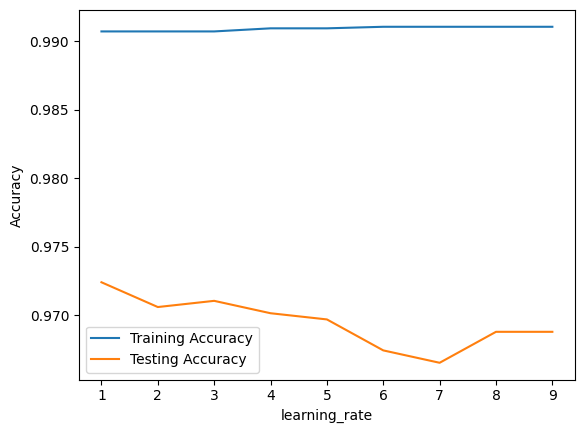

In [ ]:
# plotting the training & testing accuracy for n_estimators from 1 to 50
plt.figure(figsize=None)
plt.plot(depth, training_accuracy, label='Training Accuracy')
plt.plot(depth, test_accuracy, label='Testing Accuracy')
plt.xlabel('learning_rate')
plt.ylabel('Accuracy')
plt.legend();

In [ ]:
# storing results

storeResults('CatBoost', acc_test_cb, f1_score_test_cb, recall_score_test_cb,
             precision_score_test_cb)

### **5.9 Multilayer Perceptron (MLP)**
Kelas jaringan saraf tiruan feedforward. MLP terdiri dari setidaknya tiga lapisan node: lapisan input, satu atau lebih lapisan tersembunyi, dan lapisan output. Ini adalah model dasar dalam pembelajaran mendalam (deep learning) dan dapat digunakan untuk klasifikasi maupun regresi.

In [ ]:
# multilayer perception model
from sklearn.neural_network import MLPClassifier

# instantiate the model
mlp = MLPClassifier()
# mlp = GridSearchCV(mlpc, parameter_space)

#fit the model
mlp.fit(X_train, y_train)

MLPClassifier()

In [ ]:
#predicting the target value from model for the samples
y_train_mlp = mlp.predict(X_train)
y_test_mlp = mlp.predict(X_test)

In [ ]:
# computing the accuracy, f1_score, recall, precision of the model performance
acc_train_mlp = metrics.accuracy_score(y_train, y_train_mlp)
acc_test_mlp = metrics.accuracy_score(y_test, y_test_mlp)

print ("Multilayer Perceptron : accuracy on train data is: {:.3f}". format(acc_train_mlp))
print ("Multilayer Perceptron : accuracy on test data is: {:.3f}". format(acc_test_mlp))

f1_score_train_mlp = metrics.f1_score(y_train, y_train_mlp)
f1_score_test_mlp = metrics.f1_score(y_test, y_test_mlp)

print ("Multilayer Perceptron : f1_score on train data is: {:.3f}". format(f1_score_train_mlp))
print ("Multilayer Perceptron : f1_score on test data is: {:.3f}". format(f1_score_test_mlp))

recall_score_train_mlp = metrics.recall_score(y_train, y_train_mlp)
recall_score_test_mlp = metrics.recall_score(y_test, y_test_mlp)

print ("Multilayer Perceptron : recall on train data is: {:.3f}". format(recall_score_train_mlp))
print ("Multilayer Perceptron : recall on test data is: {:.3f}". format(recall_score_test_mlp))

precision_score_train_mlp = metrics.precision_score(y_train, y_train_mlp)
precision_score_test_mlp = metrics.precision_score(y_test, y_test_mlp)

print ("Multilayer Perceptron : precision on train data is: {:.3f}". format(precision_score_train_mlp))
print ("Multilayer Perceptron : precision on test data is: {:.3f}". format(precision_score_test_mlp))

Multilayer Perceptron : accuracy on train data is: 0.983
Multilayer Perceptron : accuracy on test data is: 0.967
Multilayer Perceptron : f1_score on train data is: 0.985
Multilayer Perceptron : f1_score on test data is: 0.971
Multilayer Perceptron : recall on train data is: 0.979
Multilayer Perceptron : recall on test data is: 0.971
Multilayer Perceptron : precision on train data is: 0.991
Multilayer Perceptron : precision on test data is: 0.971


In [ ]:
# storing results

storeResults('Multilayer Perceptron', acc_test_mlp, f1_score_test_mlp, recall_score_test_mlp,
             precision_score_test_mlp)

## **6. Comparison of Model**

In [ ]:
 # creating Dataframe
 result = pd.DataFrame({  'ml model' : ml_model,
                          'accuracy' : accuracy,
                          'f1_score' : f1_score,
                          'recall' : recall,
                          'precision' : precision,
                        })

In [ ]:
result

,ml model,accuracy,f1_score,recall,precision
0,Logistic Regression,0.934,0.941,0.953,0.930
1,K-Nearest Neighbors,0.959,0.963,0.964,0.963
2,Support Vector Machine,0.964,0.968,0.980,0.957
3,Naive Bayes,0.605,0.454,0.294,0.995
4,Decision Tree,0.960,0.964,0.962,0.967
5,Random Forest,0.966,0.970,0.976,0.964
6,Gradient Boosting,0.974,0.977,0.989,0.966
7,CatBoost,0.972,0.975,0.982,0.969
8,Multilayer Perceptron,0.967,0.971,0.971,0.971


In [ ]:
# shorting the dataframe on  accuracy
sorted_result = result.sort_values(by=['accuracy', 'f1_score'], ascending=False).reset_index(drop=True)

In [ ]:
# displaying total result
sorted_result

,ml model,accuracy,f1_score,recall,precision
0,Gradient Boosting,0.974,0.977,0.989,0.966
1,CatBoost,0.972,0.975,0.982,0.969
2,Multilayer Perceptron,0.967,0.971,0.971,0.971
3,Random Forest,0.966,0.970,0.976,0.964
4,Support Vector Machine,0.964,0.968,0.980,0.957
5,Decision Tree,0.960,0.964,0.962,0.967
6,K-Nearest Neighbors,0.959,0.963,0.964,0.963
7,Logistic Regression,0.934,0.941,0.953,0.930
8,Naive Bayes,0.605,0.454,0.294,0.995


In [ ]:
# XGboost classifier model
from xgboost import XGBClassifier

# instantiate the model
gbc = RandomForestClassifier(n_estimators=10)

#fit the model
gbc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10)

In [ ]:
import pickle

#dump information to that file
pickle.dump(gbc, open('model_randomforest.pkl', 'wb'))

Text(0, 0.5, 'Features')

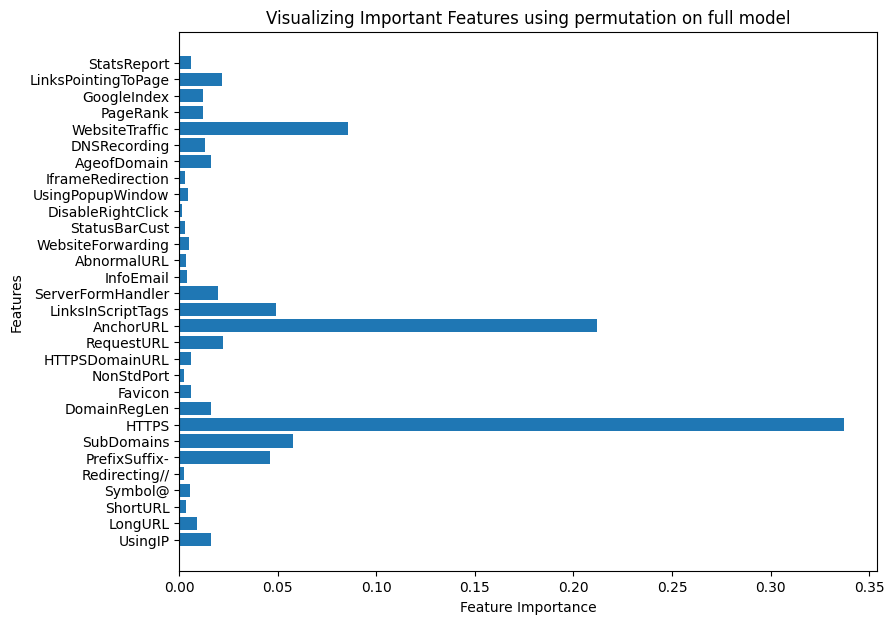

In [ ]:
# checking the feature importance in the model
plt.figure(figsize=(9, 7))
n_features = X_train.shape[1]
plt.barh(range(n_features), gbc.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.title("Visualizing Important Features using permutation on full model")
plt.xlabel('Feature Importance')
plt.ylabel('Features')

In [ ]:
# gradient boosting model
from sklearn.ensemble import GradientBoostingClassifier

# instantiate the model
gbc = GradientBoostingClassifier(n_estimators=10)

#fit the model
gbc.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=10)

In [ ]:
from sklearn.metrics import confusion_matrix

# Hitung confusion matrix untuk model Gradient Boosting
# y_test adalah nilai sebenarnya, y_test_gb adalah prediksi dari model Gradient Boosting
# Perhatikan urutan nilai pada confusion matrix: [[TN, FP], [FN, TP]]
cm_gb = confusion_matrix(y_test, y_test_gb)

# Ekstrak nilai TN dan FP dari confusion matrix
tn_gb, fp_gb, fn_gb, tp_gb = cm_gb.ravel()

# Hitung False Positive Rate (FPR)
# FPR = FP / (FP + TN)
# Hindari pembagian dengan nol jika FP + TN = 0
if (fp_gb + tn_gb) == 0:
    fpr_gb = 0
else:
    fpr_gb = fp_gb / (fp_gb + tn_gb)

print(f"False Positive Rate (FPR) for Gradient Boosting Model: {fpr_gb:.4f}")

False Positive Rate (FPR) for Gradient Boosting Model: 0.0441


In [ ]:
# import model
import pickle

#dump information to that file
pickle.dump(gbc, open('model_gradientboosting.pkl', 'wb'))

# **7. Kesimpulan**

1.   Hasil akhir dari proyek ini adalah menjelajahi berbagai model pembelajaran mesin, melakukan analisis data eksplorasi pada kumpulan data phishing dan memmahami fitur-fiturnya
1.   pada dataset phishing adalah bahwa fitur seperti "HTTPS", "AnchorURL", "WebsiteTraffic" lebih penting untuk mengklasifikasikan URL adalah URL phishing atau bukan

